<a href="https://colab.research.google.com/github/HaneenFDalvi/17_HaneenDalvi_Assignment2/blob/main/DAV_ASSIGNMENT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17| HANEEN DALVI |242A002

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


# STEP 1: Load Dataset

df = pd.read_csv("tweets.csv")

print("Dataset Columns:", df.columns)
print(df.head())

# Drop missing values
df = df.dropna()


# STEP 2: Split into Train (80%) and Test (20%)

X = df["tweets"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# STEP 3: Convert Text to TF-IDF Features
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


# STEP 4: Train Models

models = {
    "Naive Bayes": MultinomialNB(),
    "SVM (LinearSVC)": LinearSVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)

    # macro = average across all classes equally
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append([name, acc, prec, rec, f1])

    print("\n==============================")
    print(f"Model: {name}")
    print("==============================")
    print(classification_report(y_test, y_pred, zero_division=0))


# STEP 5: Compare Model Performance

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

print("\n\n========== MODEL COMPARISON TABLE ==========")
print(results_df.sort_values(by="F1-Score", ascending=False))

Dataset Columns: Index(['tweets', 'sentiment'], dtype='object')
                                              tweets sentiment
0  Chinese citizens caught faking COVID-19 tests ...   neutral
1  RT @RunesSmash: After Covid dies down, Can we ...  negative
2  RT @Neurophysik: Many COVID-19 patients recove...  positive
3  MLBは7/23 or 7/24開幕みたいだが、果たして本当に開幕できるのか。国内の感染状況...   neutral
4  RT @NicholsUprising: A Virginia physician who ...   neutral

Training samples: 80
Testing samples: 21

Model: Naive Bayes
              precision    recall  f1-score   support

    negative       1.00      0.40      0.57         5
     neutral       0.58      1.00      0.73        11
    positive       0.00      0.00      0.00         5

    accuracy                           0.62        21
   macro avg       0.53      0.47      0.43        21
weighted avg       0.54      0.62      0.52        21


Model: SVM (LinearSVC)
              precision    recall  f1-score   support

    negative       1.00      0.40   

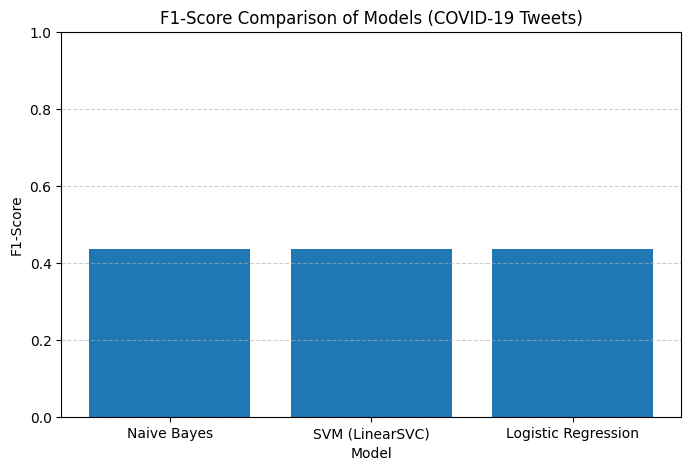

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1-Score"])

plt.title("F1-Score Comparison of Models (COVID-19 Tweets)")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()